# One-loop IDM $\leftrightarrow$ SMEFT Matching

In [1]:
import numpy as np
import sys
import os
import subprocess
import matplotlib as mpl
from matplotlib import pyplot as plt

mpl.rcParams["figure.dpi"] = 125
mpl.rcParams["savefig.dpi"] = 600


sys.path.append(os.path.abspath("/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/"))

# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport fit_utils
%aimport fit_utils.EFT_matching

import fit_utils.EFT_matching as EFT_matching

In [3]:
import pickle
vev = 246.
Mh = 125.

BP_input_dir = "/cephfs/user/mrebuzzi/phd/HiggsTools/future_projections/scan_output/IDM_scan_output"
BP_dicts_filename = f"{BP_input_dir}/Benchmark_Points_outliers_dicts.pkl"

with open(BP_dicts_filename, 'rb') as f:
    BPs = pickle.load(f)
    bp_kappas = BPs["kappas"][2::2]
    bp_EWPOs = BPs["EWPOs"][2::2]
    bp_model_pars = BPs["model_pars"][2::2]
    bp_indices = BPs["indices"][2::2]

print("BP kappas:", bp_kappas)
print("BP EWPOs:", bp_EWPOs)
print("BP model parameters:", bp_model_pars)
print("BP indices:", bp_indices)

mu2 = np.sqrt( np.array([bp["mu2sq"] for bp in bp_model_pars]) ); print("\nmu2:", mu2)
lam1 = np.array([bp["lam1"] for bp in bp_model_pars]); print("\nlam1:", lam1)
lam2 = np.array([bp["lam2"] for bp in bp_model_pars]); print("\nlam2:", lam2)
lam3 = np.array([bp["lam3"] for bp in bp_model_pars]); print("\nlam3:", lam3)
lam4 = np.array([bp["lam4"] for bp in bp_model_pars]); print("\nlam4:", lam4)
lam5 = np.array([bp["lam5"] for bp in bp_model_pars]); print("\nlam5:", lam5)
mH = np.array([bp["mH"] for bp in bp_model_pars]); print("\nmH:", mH)
mA = np.array([bp["mA"] for bp in bp_model_pars]); print("\nmA:", mA)
mHp = np.array([bp["mHp"] for bp in bp_model_pars]); print("\nmHp:", mHp)

bp_lambdas = np.array([bp["lam"] for bp in bp_kappas]); print("\nBP lambdas (1L):", bp_lambdas)
bp_lambdas_2L = np.array([bp["lam2L"] for bp in bp_kappas]); print("\nBP lambdas (2L):", bp_lambdas_2L)
bp_lambdas_2LDI = np.array([bp["lam2LDI"] for bp in bp_kappas]); print("\nBP lambdas (2LDI):", bp_lambdas_2LDI)

# IDM = EFT_matching.IDM(l1=lam1, l3=lam3, l4=lam4, l5=lam5, mu2=mu2)
IDM = EFT_matching.IDM.from_masses(mH=mH, mA=mA, mHp=mHp, mu2=mu2)

# Getting the matched Wilson coefficients at the NP scale
lamNP_match = mu2
matched_WCs = IDM.get_coefficients(lamNP_match=lamNP_match)
print("\nMatched Wilson coefficients at lamNP = mu2:")
for wc_name, wc_values in matched_WCs.items():
    print(f"{wc_name}: {wc_values}")

matched_kappa_lambdas = IDM.get_kappa_lambda_SMEFT_match(lamNP_match=lamNP_match)
print("Matched SMEFT kappa_lambda at lamNP = mu2:\n", matched_kappa_lambdas)
print("Model kappa_lambda predictions: ", bp_lambdas)

# Wilson coefficients
CH    = matched_WCs["CH"]
CHbox = matched_WCs["CHbox"]
CHD   = matched_WCs["CHD"]

# Z->Zh BSM to SM ratios
dZZh_SMEFT_sqrts0 = IDM.get_ZtoZH_SMEFT_match(sqrts=0.0)
dZZh_SMEFT_sqrts240 = IDM.get_ZtoZH_SMEFT_match(sqrts=240.0)
dZZh_SMEFT_sqrts365 = IDM.get_ZtoZH_SMEFT_match(sqrts=365.0)

BP kappas: [{'uu': 0.997497286095468, 'dd': 0.997497286095468, 'ss': 0.997497286095468, 'cc': 0.997497286095468, 'bb': 0.997497286095468, 'tt': 0.997497286095468, 'ee': 0.997497286095468, 'mumu': 0.997497286095468, 'tautau': 0.997497286095468, 'ZZ_0': 0.99803003617002, 'ZZ_240': 0.9989225157021105, 'ZZ_365': 0.9985818760113092, 'ZZ_500': 0.9988812072771296, 'ZZ_550': 0.9990824850147142, 'ZZ': 0.9965497536506333, 'WW': 0.9965497536506333, 'gg': 0.997497286095468, 'lam': 1.1209067864736006, 'gamgam': 0.9821975068074829, 'Zgam': 0.9934043522024448, 'lam2L': 1.1445897207900972, 'lam2LDI': 1.1396677034680394, 'ZZ_0_with_WFR': 0.9978303652641312, 'ZZ_240_with_WFR': 0.9987243848566684, 'ZZ_365_with_WFR': 0.9983832518255341, 'ZZ_500_with_WFR': 0.9986830228142305, 'ZZ_550_with_WFR': 0.9988845456470622, 'ZZ_0_with_WFR_no_BSM': 1.000295978534025, 'ZZ_240_with_WFR_no_BSM': 1.000910770055903, 'ZZ_365_with_WFR_no_BSM': 1.0001978962466753, 'ZZ_500_with_WFR_no_BSM': 0.9999013780758704, 'ZZ_550_with_WF

### Sorting arrays according to the value of $\kappa_\lambda^{(1)}$

In [4]:
# Sort arrays
sort_indices = np.argsort(bp_lambdas)
print("Sort indices:", sort_indices)

bp_lambdas = bp_lambdas[sort_indices]
bp_lambdas_2L = bp_lambdas_2L[sort_indices]
bp_lambdas_2LDI = bp_lambdas_2LDI[sort_indices]
matched_kappa_lambdas = matched_kappa_lambdas[sort_indices]

mu2 = mu2[sort_indices]
lam1 = lam1[sort_indices]
lam2 = lam2[sort_indices]
lam3 = lam3[sort_indices]
lam4 = lam4[sort_indices]
lam5 = lam5[sort_indices]

mH = mH[sort_indices]
mA = mA[sort_indices]
mHp = mHp[sort_indices]

CH    = CH    [sort_indices]
CHbox = CHbox [sort_indices]
CHD   = CHD   [sort_indices]

dZZh_SMEFT_sqrts0   = dZZh_SMEFT_sqrts0  [sort_indices]
dZZh_SMEFT_sqrts240 = dZZh_SMEFT_sqrts240[sort_indices]
dZZh_SMEFT_sqrts365 = dZZh_SMEFT_sqrts365[sort_indices]

Sort indices: [0 1 2 3 4 5 6 7 8 9]


#### Modifying $\Lambda_{\text{NP}}$

In [26]:
# Getting the matched Wilson coefficients at the NP scale
lamNP_match = mHp
lamNP_tex = r"m_{H^+}"
matched_WCs = IDM.get_coefficients(lamNP_match=lamNP_match)
print("\nMatched Wilson coefficients at lamNP = mu2:")
for wc_name, wc_values in matched_WCs.items():
    print(f"{wc_name}: {wc_values}")

matched_kappa_lambdas = IDM.get_kappa_lambda_SMEFT_match(lamNP_match=lamNP_match)
print("Matched SMEFT kappa_lambda at lamNP = mu2:\n", matched_kappa_lambdas)
print("Model kappa_lambda predictions: ", bp_lambdas)

# Wilson coefficients
CH    = matched_WCs["CH"]
CHbox = matched_WCs["CHbox"]
CHD   = matched_WCs["CHD"]

# Z->Zh BSM to SM ratios
dZZh_SMEFT_sqrts0 = IDM.get_ZtoZH_SMEFT_match(sqrts=0.0)
dZZh_SMEFT_sqrts240 = IDM.get_ZtoZH_SMEFT_match(sqrts=240.0)
dZZh_SMEFT_sqrts365 = IDM.get_ZtoZH_SMEFT_match(sqrts=365.0)

# Sort arrays
sort_indices = np.argsort(bp_lambdas)
print("Sort indices:", sort_indices)

bp_lambdas = bp_lambdas[sort_indices]
bp_lambdas_2L = bp_lambdas_2L[sort_indices]
bp_lambdas_2LDI = bp_lambdas_2LDI[sort_indices]
matched_kappa_lambdas = matched_kappa_lambdas[sort_indices]

mu2 = mu2[sort_indices]
lam1 = lam1[sort_indices]
lam2 = lam2[sort_indices]
lam3 = lam3[sort_indices]
lam4 = lam4[sort_indices]
lam5 = lam5[sort_indices]

mH = mH[sort_indices]
mA = mA[sort_indices]
mHp = mHp[sort_indices]

CH    = CH    [sort_indices]
CHbox = CHbox [sort_indices]
CHD   = CHD   [sort_indices]

dZZh_SMEFT_sqrts0   = dZZh_SMEFT_sqrts0  [sort_indices]
dZZh_SMEFT_sqrts240 = dZZh_SMEFT_sqrts240[sort_indices]
dZZh_SMEFT_sqrts365 = dZZh_SMEFT_sqrts365[sort_indices]


Matched Wilson coefficients at lamNP = mu2:
CH: [-3.88651466e-07 -3.16073699e-06 -5.26146470e-06 -7.44539295e-06
 -9.76778095e-06 -1.19124461e-05 -1.44477967e-05 -1.68460424e-05
 -1.84179041e-05 -2.26913838e-05]
CHbox: [-2.07419703e-08 -7.87345320e-08 -1.05102091e-07 -1.29767391e-07
 -1.51513261e-07 -1.73826279e-07 -1.96082160e-07 -2.14054445e-07
 -2.32493589e-07 -2.62840568e-07]
CHD: [-1.57575251e-08 -9.09932509e-09 -9.73470971e-09 -5.89983389e-09
 -6.94841149e-09 -7.79801978e-09 -5.97091788e-09 -7.28524237e-09
 -4.25170752e-09 -2.08963530e-09]
CHW: [8.90332902e-10 1.35785092e-09 1.46335990e-09 1.63589849e-09
 1.73284109e-09 1.94079178e-09 1.93869479e-09 2.07905810e-09
 2.41263075e-09 2.58882753e-09]
CHB: [2.56103198e-10 3.90584199e-10 4.20933731e-10 4.70564251e-10
 4.98449674e-10 5.58266441e-10 5.57663246e-10 5.98038583e-10
 6.93990357e-10 7.44673151e-10]
CHWB: [-4.18965840e-10 -4.79585180e-10 -5.11350388e-10 -5.64467456e-10
 -6.02390425e-10 -6.83772139e-10 -6.64838880e-10 -7.278078

### $\kappa_\lambda$

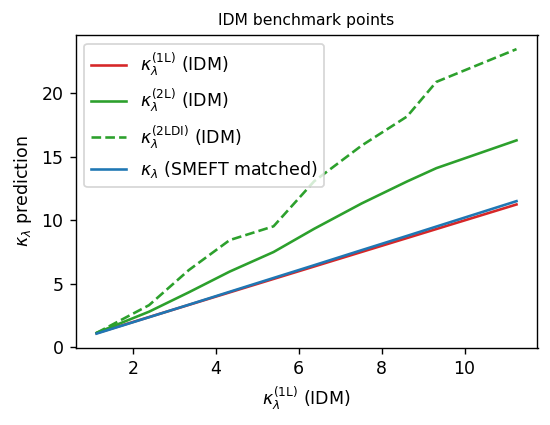

In [27]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, bp_lambdas, color='tab:red', label=r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.plot(bp_lambdas, bp_lambdas_2L, color='tab:green', label=r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (IDM)')
ax.plot(bp_lambdas, bp_lambdas_2LDI, color='tab:green', ls="--", label=r'$\kappa_{\lambda}^{\mathrm{(2LDI)}}$ (IDM)')
ax.plot(bp_lambdas, matched_kappa_lambdas, color='tab:blue', label=r'$\kappa_{\lambda}$ (SMEFT matched)')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_ylabel(r'$\kappa_{\lambda}$ prediction')
plt.title("IDM benchmark points",fontsize=9)
ax.legend()
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/kappa_lambda_matching_comparison.pdf")

### $\kappa_\lambda$ (Zoomed-in version)

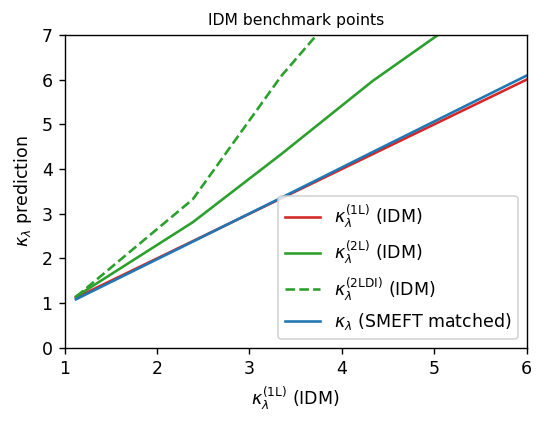

In [33]:
ax.set_xlim(1,6)
ax.set_ylim(0,7)
fig.savefig(f"{plot_dir}/kappa_lambda_matching_comparison_zoom.pdf")
fig

### Wilson coefficients

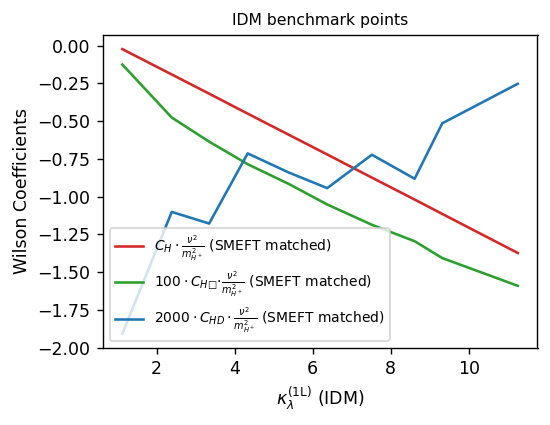

In [20]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, CH*vev**2, color='tab:red', label=r'$C_{H}\cdot \frac{\nu^2}{' + lamNP_tex + r'^{2}}$ (SMEFT matched)')
ax.plot(bp_lambdas, 100*CHbox*vev**2, color='tab:green', label='$100\cdot C_{H\u25A1}$'+r'$\cdot \frac{\nu^2}{' + lamNP_tex + r'^{2}}$ (SMEFT matched)')
ax.plot(bp_lambdas, 2000*CHD*vev**2, color='tab:blue', label=r'$2000\cdot C_{HD}\cdot \frac{\nu^2}{' + lamNP_tex + r'^{2}}$ (SMEFT matched)')
# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.set_ylabel(r'Wilson Coefficients')
ax.legend(fontsize=8)
plt.title("IDM benchmark points",fontsize=9)
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/WCs_matching_comparison.pdf")

### IDM parameters

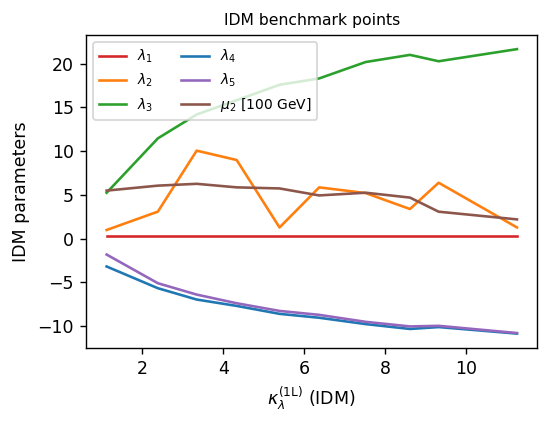

In [21]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, lam1, color='tab:red', label=r'$\lambda_{1}$')
ax.plot(bp_lambdas, lam2, color='tab:orange', label=r'$\lambda_{2}$')
ax.plot(bp_lambdas, lam3, color='tab:green', label=r'$\lambda_{3}$')
ax.plot(bp_lambdas, lam4, color='tab:blue', label=r'$\lambda_{4}$')
ax.plot(bp_lambdas, lam5, color='tab:purple', label=r'$\lambda_{5}$')
ax.plot(bp_lambdas, mu2/100., color='tab:brown', label=r'$\mu_{2}$ [100 GeV]')

# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.set_ylabel(r'IDM parameters')
ax.legend(fontsize=8, ncol=2)
plt.title("IDM benchmark points",fontsize=9)
plt.tight_layout()

plt.savefig(f"{plot_dir}/IDM_parameters_matching_comparison.pdf")

### IDM parameters (BSM masses)

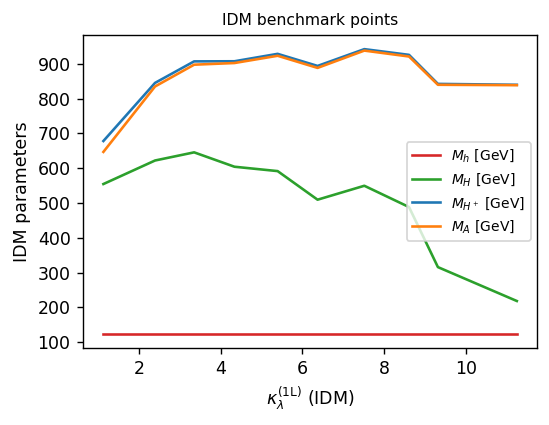

In [22]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, np.full_like(mH, Mh),  color='tab:red', label=r'$M_{h}$ [GeV]')
ax.plot(bp_lambdas, mH,  color='tab:green', label=r'$M_{H}$ [GeV]')
ax.plot(bp_lambdas, mHp, color='tab:blue', label=r'$M_{H^+}$ [GeV]')
ax.plot(bp_lambdas, mA,  color='tab:orange', label=r'$M_{A}$ [GeV]')

# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.set_ylabel(r'IDM parameters')
ax.legend(fontsize=8, ncol=1)
plt.title("IDM benchmark points",fontsize=9)
plt.tight_layout()

plt.savefig(f"{plot_dir}/IDM_parameters_masses_matching_comparison.pdf")

In [23]:
# Quick test
kappa_lambda_last_BP = 1 + (vev**2) * ( - 2 * vev**2 / Mh**2 * CH[-1] )
print("\nKappa_lambda of last BP from matched CH:", kappa_lambda_last_BP)
print("Matched CH for last BP:", CH[-1]*vev**2)


Kappa_lambda of last BP from matched CH: 11.636809469645184
Matched CH for last BP: -1.3731917836870084


### $Z\to Zh$ BSM to SM ratio
#### Cross-checking the analytical formula with the values stored for the IDM BPs

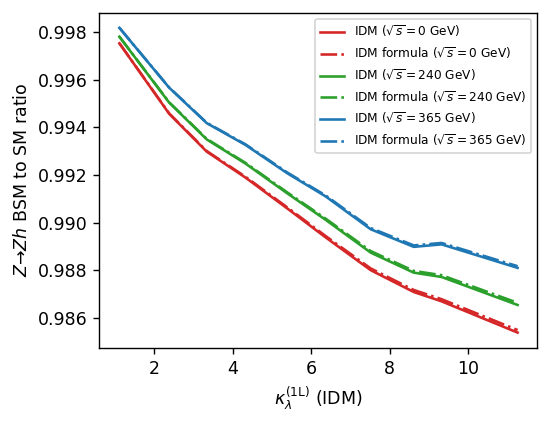

In [24]:
dZZh_IDM_BPs_sqrt0   = np.array([bp["ZZ_0_pure_1L_BSM"]   for bp in bp_kappas])
dZZh_IDM_BPs_sqrt240 = np.array([bp["ZZ_240_pure_1L_BSM"] for bp in bp_kappas])
dZZh_IDM_BPs_sqrt365 = np.array([bp["ZZ_365_pure_1L_BSM"] for bp in bp_kappas])

dZZh_IDM_BPs_formula_sqrt0   = IDM.get_ZtoZH_IDM(sqrts=0.0)
dZZh_IDM_BPs_formula_sqrt240 = IDM.get_ZtoZH_IDM(sqrts=240.0)
dZZh_IDM_BPs_formula_sqrt365 = IDM.get_ZtoZH_IDM(sqrts=365.0)


fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, dZZh_IDM_BPs_sqrt0,  color='tab:red', linestyle='solid',  label=r'IDM ($\sqrt{s}=0$ GeV)')
ax.plot(bp_lambdas, 1+dZZh_IDM_BPs_formula_sqrt0, color='tab:red', linestyle='-.', label=r'IDM formula ($\sqrt{s}=0$ GeV)')

ax.plot(bp_lambdas, dZZh_IDM_BPs_sqrt240,  color='tab:green', linestyle='solid',  label=r'IDM ($\sqrt{s}=240$ GeV)')
ax.plot(bp_lambdas, 1+dZZh_IDM_BPs_formula_sqrt240, color='tab:green', linestyle='-.', label=r'IDM formula ($\sqrt{s}=240$ GeV)')

ax.plot(bp_lambdas, dZZh_IDM_BPs_sqrt365,  color='tab:blue',  linestyle='solid',  label=r'IDM ($\sqrt{s}=365$ GeV)')
ax.plot(bp_lambdas, 1+dZZh_IDM_BPs_formula_sqrt365, color='tab:blue',  linestyle='-.', label=r'IDM formula ($\sqrt{s}=365$ GeV)')

# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.set_ylabel(r"$Z\to Zh$ BSM to SM ratio")
ax.legend(fontsize=7, ncol=1)
# ax.set_ylim(0.95, 1.0)
plt.tight_layout()

plt.savefig(f"{plot_dir}/ZZh_couplings_matching_comparison.pdf")

#### IDM vs. SMEFT comparison
##### $\sqrt{s} = 0$ GeV

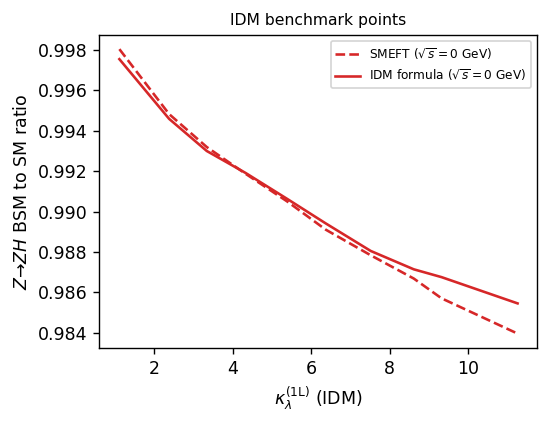

In [117]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, 1+dZZh_SMEFT_sqrts0, color='tab:red', linestyle='dashed', label=r'SMEFT ($\sqrt{s}=0$ GeV)')
ax.plot(bp_lambdas, 1+dZZh_IDM_BPs_formula_sqrt0, color='tab:red', linestyle='-', label=r'IDM formula ($\sqrt{s}=0$ GeV)')
plt.title("IDM benchmark points",fontsize=9)

ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.set_ylabel(r"$Z\to ZH$ BSM to SM ratio")
ax.legend(fontsize=7, ncol=1)
# ax.set_ylim(0.95, 1.0)
plt.tight_layout()

plt.savefig(f"{plot_dir}/ZZh_0_couplings_matching_comparison.pdf")

##### $\sqrt{s} = 240$ GeV

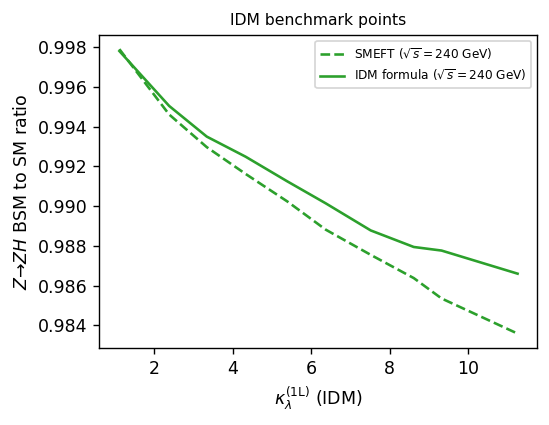

In [118]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, 1+dZZh_SMEFT_sqrts240, color='tab:green', linestyle='dashed', label=r'SMEFT ($\sqrt{s}=240$ GeV)')
ax.plot(bp_lambdas, 1+dZZh_IDM_BPs_formula_sqrt240, color='tab:green', linestyle='-', label=r'IDM formula ($\sqrt{s}=240$ GeV)')
plt.title("IDM benchmark points",fontsize=9)

ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.set_ylabel(r"$Z\to ZH$ BSM to SM ratio")
ax.legend(fontsize=7, ncol=1)
# ax.set_ylim(0.95, 1.0)
plt.tight_layout()

plt.savefig(f"{plot_dir}/ZZh_240_couplings_matching_comparison.pdf")

##### $\sqrt{s} = 365$ GeV

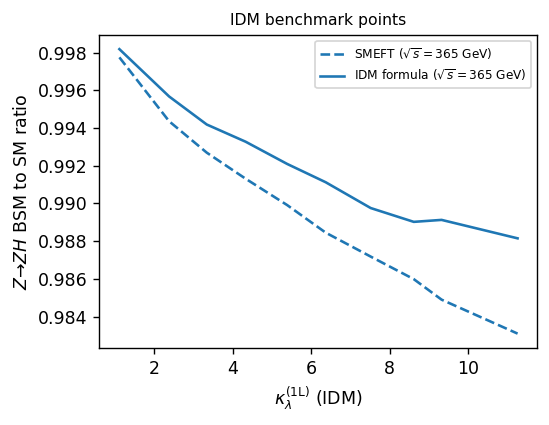

In [119]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, 1+dZZh_SMEFT_sqrts365, color='tab:blue', linestyle='dashed', label=r'SMEFT ($\sqrt{s}=365$ GeV)')
ax.plot(bp_lambdas, 1+dZZh_IDM_BPs_formula_sqrt365, color='tab:blue', linestyle='-', label=r'IDM formula ($\sqrt{s}=365$ GeV)')
plt.title("IDM benchmark points",fontsize=9)

ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.set_ylabel(r"$Z\to ZH$ BSM to SM ratio")
ax.legend(fontsize=7, ncol=1)
# ax.set_ylim(0.95, 1.0)
plt.tight_layout()

plt.savefig(f"{plot_dir}/ZZh_365_couplings_matching_comparison.pdf")

In [57]:
# ax.set_ylim(0.94, 1.008)
# fig.savefig(f"{plot_dir}/ZZh_couplings_matching_comparison_zoom.pdf")
# fig

### Cross-check: testing the `get_BSM_masses()` function

In [59]:
mH_formula, mA_formula, mHp_formula = IDM.get_BSM_masses()
print(f"mH = {mH}")
print(f"mH (formula) = {mH_formula}")
print(f"mH difference = {mH - mH_formula}")

print(f"\nmA = {mA}")
print(f"mA (formula) = {mA_formula}")
print(f"mA difference = {mA - mA_formula}")

print(f"\nmHp = {mHp}")
print(f"mHp (formula) = {mHp_formula}")
print(f"mHp difference = {mHp - mHp_formula}")

mH = [554.56742675 622.15467211 645.56111752 604.27081307 591.71024225
 509.59825321 549.61779022 488.45548743 315.98326629 218.62433154]
mH (formula) = [554.56742675 622.15467211 645.56111752 604.27081307 591.71024225
 509.59825321 549.61779022 488.45548743 315.98326629 218.62433154]
mH difference = [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  1.13686838e-13 -5.68434189e-14  0.00000000e+00 -5.68434189e-14
 -5.68434189e-14  8.52651283e-14]

mA = [646.82577261 834.75825277 897.32117184 902.07603173 922.95603984
 888.09829276 937.79238476 920.81044239 839.62823708 838.45373946]
mA (formula) = [646.82577261 834.75825277 897.32117184 902.07603173 922.95603984
 888.09829276 937.79238476 920.81044239 839.62823708 838.45373946]
mA difference = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

mHp = [678.09236912 845.05538978 906.84467762 907.17900217 928.45793132
 893.74355164 941.9849384  925.57135169 842.18963192 839.61666905]
mHp (formula) = [678.09236912 845.05538978 906.84467762 907

### Cross-checking implementation in `EFT_matching.py` with Henning's test

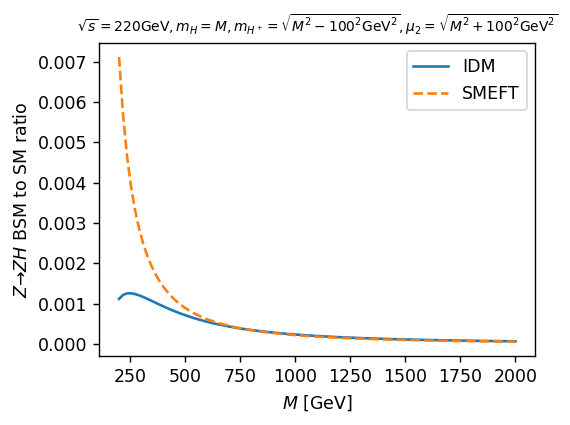

In [99]:
M_range = np.linspace(200, 2000, 100)
sqrts_val = 220
mH = M_range; mA = np.sqrt(M_range**2 + 400**2); mHp = np.sqrt(M_range**2 - 100**2); mu2 = np.sqrt(M_range**2 + 100**2)
lamNP_old = mu2
lamNP_new = mHp

IDM_scenario = EFT_matching.IDM.from_masses(mH=mH, mA=mA, mHp=mHp, mu2=mu2)
IDM_vals = IDM_scenario.get_ZtoZH_IDM(sqrts=sqrts_val)
SMEFT_vals = IDM_scenario.get_ZtoZH_SMEFT_match(sqrts=sqrts_val) * (lamNP_old/lamNP_new)**2 # Rescaling SMEFT values to new lambda_NP

fig = plt.figure(figsize=(4.5,3.5))
plt.plot(M_range, IDM_vals, label="IDM")
plt.plot(M_range, SMEFT_vals, label="SMEFT", linestyle="dashed")
plt.title(
    r"$\sqrt{s} = 220\mathrm{GeV},m_H = M, m_{H^+} = \sqrt{M^2 - 100^2\mathrm{GeV}^2}, \mu_2 = \sqrt{M^2 + 100^2\mathrm{GeV}^2}$",
    fontsize=8
)
plt.xlabel(r"$M$ [GeV]")
plt.ylabel(r"$Z\to ZH$ BSM to SM ratio")
# plt.ylim(0.0, 0.005)
plt.legend()
plt.tight_layout()
# plt.show()
plt.savefig(f"{plot_dir}/ZZh_couplings_matching_comparison_Henning.pdf")

In [81]:
# Quick test
from pyCollier import db0 as dB0
a = np.array([100**2, 100**2])
b = np.array([200**2, 300**2])
c = np.array([200**2, 200**2])
dB0(a,b,c)
# pyCollier loop fuctions are not vectorized!!

(4.386818141942566e-06+0j)